In [1]:
# --- Rosenbrock Function using PyTorch ---
# def f(w):
#     """Rosenbrock function for optimization."""
#     w1, w2 = w
#     return (1 - w1)**2 + 100 * (w2 - w1**2)**2

def f(w):
    w1, w2 = w
    return (w1 - 1)**2 + (w2 - 1)**2

In [2]:
N_ITER = 300

In [3]:
def optimizer_trajectory(optimizer, w, n_iter=N_ITER):
    """
    Computes the optimization trajectory for a given PyTorch optimizer.
    # """
    # w = initial_w.clone().detach().requires_grad_(True)
    
    metrics = {
        "fs": [],
        "gs": [],
        "ws": [],
    }

    # Initial state
    initial_loss = f(w)
    initial_loss.backward()
    metrics["fs"].append(initial_loss.item())
    metrics["gs"].append(torch.linalg.norm(w.grad).item())
    metrics["ws"].append(w.clone().detach())
    optimizer.zero_grad()

    # Optimization loop
    for _ in range(n_iter):
        optimizer.zero_grad()
        loss = f(w)
        loss.backward()
        
        # --- MODIFICATION HERE ---
        # Store the full gradient tensor, not just its norm
        if w.grad is not None:
            metrics["gs"].append(w.grad.clone().detach())
        else:
            # Handle cases where gradient might be None
            metrics["gs"].append(torch.zeros_like(w))
        
        optimizer.step()

        
    return metrics

In [ ]:
import math
def optimizer_trajectory(optimizer, w, n_iter=N_ITER):
    """
    Computes the optimization trajectory and gradient angles.
    """
    # print("here")
    metrics = {
        "gs": [],
        "fs": [],          # Loss values
        "ws": [],          # Weight positions
        "g_angles": [],    # Gradient angle in radians
        "g_cos": [],       # Cosine of the gradient angle
        "g_sin": [],       # Sine of the gradient angle
    }

    initial_loss = f(w)
    initial_loss.backward()
    metrics["fs"].append(initial_loss.item())
    metrics["gs"].append(torch.linalg.norm(w.grad).item())
    metrics["ws"].append(w.clone().detach())
    optimizer.zero_grad()

    # Optimization loop
    for _ in range(n_iter):
        optimizer.zero_grad()
        loss = f(w)
        loss.backward()
        
        if w.grad is not None and not torch.isnan(w.grad).any():
            # --- MODIFICATION: Calculate and store angle ---
            grad = w.grad.detach()
            # Use atan2(dy, dx) to get the angle in radians
            angle = torch.atan2(grad[1], grad[0])
            if math.isnan(angle.item()):
                print(grad)
            
            metrics["g_angles"].append(angle.item())
            metrics["g_cos"].append(torch.cos(angle).item())
            metrics["g_sin"].append(torch.sin(angle).item())

        else:
            # Handle cases where gradient is None
            print("grad is nan")
            metrics["g_angles"].append(0.0)
            metrics["g_cos"].append(1.0)
            metrics["g_sin"].append(0.0)
        
        optimizer.step()

        # Record metrics after the step
        metrics["fs"].append(loss.item())
        metrics["ws"].append(w.clone().detach())
        metrics["gs"].append(torch.linalg.norm(w.grad).item())
  
    return metrics

Running optimizer: AdaGramPS_1...
here
Running optimizer: AdaGramPS_2...
here
Running optimizer: AdaGramPS_3...
here
Running optimizer: AdaGramPS_4...
here
Running optimizer: AdaGramPS_5...
here
Running optimizer: Kate...
here
Running optimizer: Adagrad...
here
Running optimizer: SGD...
here
All optimizations complete.


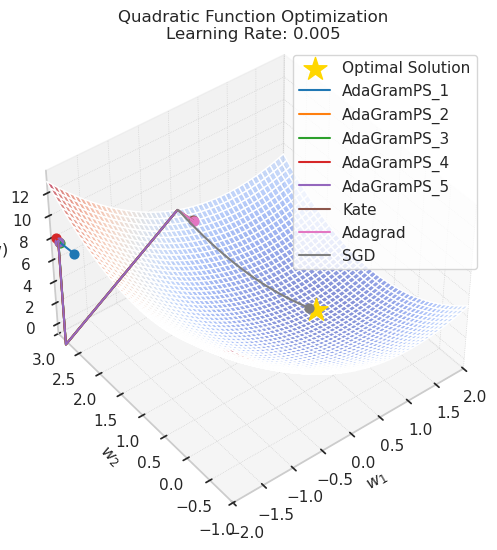

In [9]:
import torch
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LogNorm

import libcontext
from src.adagram_optimizers.AdagramVanilla import AdaGramVanilla
from src.adagram_optimizers.AdagramPS import AdaGramPS
from src.adagram_optimizers.Shampoo import Shampoo
from src.adagram_optimizers.FullAdagrad import FullAdaGrad
from src.adagram_optimizers.Kate import KATE

from IPython.display import HTML
import matplotlib

matplotlib.rcParams['animation.embed_limit'] = 50

# --- Matplotlib Configuration ---
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['grid.linestyle'] = ":"
plt.rcParams['figure.dpi'] = 100

# --- Simulation Parameters ---
# N_ITER = 2000
TOTAL_FRAMES = 300
LR = 5e-3
MOMENTUM = 0.9
W_0 = torch.tensor([0.1, 3.0])
BOUNDS_W1 = (-2, 2)
BOUNDS_W2 = (-1, 3)

# --- Optimizer Configuration ---
# Note: Replaced Optax optimizers with PyTorch equivalents.
optimizers_config = [
    {
        'name': 'AdaGramPS_1',
        'optimizer_class': AdaGramPS,
        'params': {'lr': LR, 'max_rank': 1},
    },
    {
        'name': 'AdaGramPS_2',
        'optimizer_class': AdaGramPS,
        'params': {'lr': LR, 'max_rank': 2},
    },
    {
        'name': 'AdaGramPS_3',
        'optimizer_class': AdaGramPS,
        'params': {'lr': LR, 'max_rank': 3},
    },
    {
        'name': 'AdaGramPS_4',
        'optimizer_class': AdaGramPS,
        'params': {'lr': LR, 'max_rank': 4},
    },
    {
        'name': 'AdaGramPS_5',
        'optimizer_class': AdaGramPS,
        'params': {'lr': LR, 'max_rank': 5},
    },
    {
        'name': 'Kate',
        'optimizer_class': KATE,
        'params': {'lr': LR},
    },
    {
        'name': 'Adagrad',
        'optimizer_class': torch.optim.Adagrad,
        'params': {'lr': LR},
    },
    {
        'name': 'SGD',
        'optimizer_class': torch.optim.SGD,
        'params': {'lr': LR},
    },
]

# --- Automatically Assign Distinct Colors ---

# 1. Get the total number of optimizers
num_optimizers = len(optimizers_config)

# 2. Get a colormap. 'tab10' provides 10 distinct colors.
# For more than 10, use 'tab20'.
colormap = plt.get_cmap('tab10')

# 3. Loop through your config and assign a color to each entry
for i, opt_config in enumerate(optimizers_config):
    # The colormap returns an RGBA tuple. Matplotlib handles this perfectly.
    # We use the modulo operator (%) to cycle through the 10 colors if you have more than 10 optimizers.
    opt_config['color'] = colormap(i % 10)

# --- Trajectory Calculation Logic for PyTorch ---


# --- Run Optimization for All Configured Optimizers ---
metrics = {}
for opt_config in optimizers_config:
    # Create the tensor that will be optimized for this run
    w_to_optimize = W_0.clone().detach().requires_grad_(True)
    
    # Instantiate the optimizer with THIS specific tensor
    optimizer_instance = opt_config['optimizer_class']([w_to_optimize], **opt_config['params'])
    
    print(f"Running optimizer: {opt_config['name']}...")
    # Pass both the optimizer and the tensor it's tracking
    metrics[opt_config['name']] = optimizer_trajectory(optimizer_instance, w_to_optimize)

print("All optimizations complete.")
# --- 3D Plot Setup ---
# fig, ax = plt.subplots(subplot_kw=dict(projection='3d', azim=-128.0, elev=43.0, computed_zorder=False), figsize=(8, 6))

# # Create the surface plot
# x_grid = np.linspace(*BOUNDS_W1, 50)
# y_grid = np.linspace(*BOUNDS_W2, 50)
# X, Y = np.meshgrid(x_grid, y_grid)
# Z = np.array([f(torch.tensor([x_val, y_val])).item() for x_val, y_val in zip(X.flatten(), Y.flatten())]).reshape(X.shape)

# ax.plot_surface(X, Y, Z, alpha=0.6, cmap='coolwarm', norm=LogNorm())
# ax.set_xlabel(r'$w_1$')
# ax.set_ylabel(r'$w_2$')
# ax.set_xlim(BOUNDS_W1)
# ax.set_ylim(BOUNDS_W2)
# ax.set_zlim([0, 2500])
# ax.zaxis.set_rotate_label(False)
# ax.set_zlabel('f(w)', rotation=0)
# ax.set_title(f'Rosenbrock Function Optimization in PyTorch\nLearning Rate: {LR}')

fig, ax = plt.subplots(subplot_kw=dict(projection='3d', azim=-128.0, elev=43.0, computed_zorder=False), figsize=(8, 6))

# Create the surface plot
x_grid = np.linspace(*BOUNDS_W1, 50)
y_grid = np.linspace(*BOUNDS_W2, 50)
X, Y = np.meshgrid(x_grid, y_grid)
Z = np.array([f(torch.tensor([x_val, y_val])).item() for x_val, y_val in zip(X.flatten(), Y.flatten())]).reshape(X.shape)

# FIX: Removed LogNorm as it's not suitable for this simple quadratic function.
ax.plot_surface(X, Y, Z, alpha=0.6, cmap='coolwarm')

ax.set_xlabel(r'$w_1$')
ax.set_ylabel(r'$w_2$')
ax.set_xlim(BOUNDS_W1)
ax.set_ylim(BOUNDS_W2)

# FIX: Removed the fixed z-limit to allow Matplotlib to auto-scale.
# ax.set_zlim([0, 2500]) 

ax.zaxis.set_rotate_label(False)
ax.set_zlabel('f(w)', rotation=0)

# Changed title to reflect the actual function being plotted
ax.set_title(f'Quadratic Function Optimization\nLearning Rate: {LR}')

# Plot the global minimum
global_min = torch.tensor([1.0, 1.0])
ax.scatter(global_min[0], global_min[1], f(global_min).item(), color='gold', marker='*', s=300, label='Optimal Solution')

# Initialize empty lines for trajectories - extract the Line3D object from the list
# --- Animation setup ---
# Initialize empty lines for trajectories
lines = [ax.plot([], [], [], color=opt['color'], label=opt['name'])[0] for opt in optimizers_config]

# Initialize scatter plots for the "head" of each trajectory
# We start with empty data
head_scatters = [ax.scatter([], [], [], color=opt['color'], s=40) for opt in optimizers_config]
ax.legend(loc='upper right')



# Pre-process trajectories to NumPy for speed
np_metrics = {}
for name, data in metrics.items():
    np_metrics[name] = {
        "ws": torch.stack(data["ws"]).numpy(),
        "fs": np.array(data["fs"])
    }

def animate(i):
    """
    Optimized animation function that only updates data.
    """
    skip_rate = max(1, N_ITER // TOTAL_FRAMES)
    current_iter = min(i * skip_rate, N_ITER - 1)
    
    # Iterate through optimizers and update their corresponding line and scatter
    for idx, opt_config in enumerate(optimizers_config):
        name = opt_config['name']
        
        # Get the pre-calculated NumPy data
        w_traj = np_metrics[name]["ws"]
        f_traj = np_metrics[name]["fs"]
        
        # --- Update Line Data ---
        # Update the full trajectory up to the current point
        lines[idx].set_data(w_traj[:current_iter+1, 0], w_traj[:current_iter+1, 1])
        lines[idx].set_3d_properties(f_traj[:current_iter+1])
        
        # --- Update Scatter (Head) Data ---
        # We need to provide the coordinates in a list format for 3D scatters
        head_scatters[idx]._offsets3d = (
            [w_traj[current_iter, 0]], 
            [w_traj[current_iter, 1]], 
            [f_traj[current_iter]]
        )
        
    # The list of artists to be updated
    return lines + head_scatters

# --- Create the animation ---
ani = FuncAnimation(
    fig,
    animate,
    frames=TOTAL_FRAMES,
    interval=33,  # Approx 30 FPS
    blit=True
)

ani.save(
    "optimization_animation_sym.mp4", 
    writer='ffmpeg', 
    fps=30,
    # This preset tells the encoder to use the fastest settings
    extra_args=['-vcodec', 'libx264', '-preset', 'ultrafast']
)

# Display or save
# HTML(ani.to_jshtml())


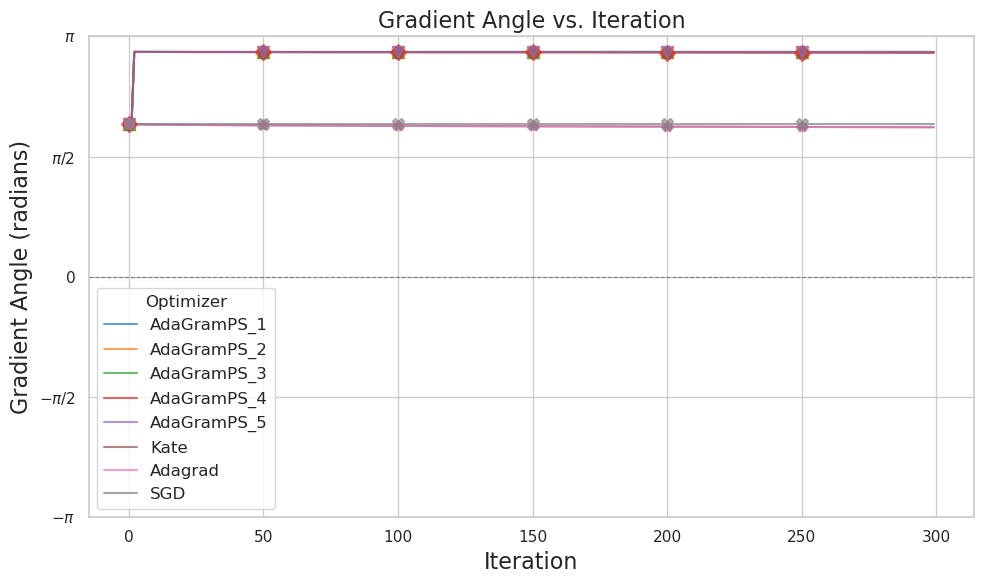

In [10]:
import math
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- 1. Data Preparation: Convert to a Long-Form DataFrame ---
# This is the most important step for using Seaborn.
# We transform the data from a dictionary to a list of records.
data_list = []
for opt_name, values in metrics.items():
    for i, angle in enumerate(values["g_angles"]):
        data_list.append({
            "Optimizer": opt_name,
            "Iteration": i,
            "Gradient Angle": angle,
            "Norm": values["gs"][i]
        })

df = pd.DataFrame(data_list)

# --- 2. Plotting with Seaborn ---
# Set the plot style and size
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Define the color palette and markers from your original config
palette = {opt['name']: opt['color'] for opt in optimizers_config}
markers = ['o', 's', '^', 'D', 'v', '*', 'p', 'X']

# Create the main line plot using Seaborn's lineplot function
# Seaborn handles the legend and colors automatically based on the 'hue' column.
sns.lineplot(
    data=df,
    x="Iteration",
    y="Gradient Angle",
    hue="Optimizer",
    palette=palette,
    alpha=0.7,
    ax=ax
)

# --- 3. Add Markers Manually ---
# We still add markers separately to have full control over the `markevery` logic.
for i, name in enumerate(df['Optimizer'].unique()):
    optimizer_df = df[df['Optimizer'] == name]
    ax.plot(
        optimizer_df["Iteration"],
        optimizer_df["Gradient Angle"],
        color=palette[name],
        linestyle='None',
        marker=markers[i % len(markers)],
        markevery=50,
        markersize=8,
        alpha=0.6,
        label='_nolegend_'
    )

# --- 4. Final Formatting ---
# Use Matplotlib functions to apply the final custom touches
ax.set_title('Gradient Angle vs. Iteration', fontsize=16)
ax.set_xlabel('Iteration', fontsize=16)
ax.set_ylabel('Gradient Angle (radians)', fontsize=16)

ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_yticks([-math.pi, -math.pi/2, 0, math.pi/2, math.pi])
ax.set_yticklabels([r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])

# Improve the legend generated by Seaborn
ax.legend(title='Optimizer', fontsize=12)

plt.tight_layout()
plt.show()



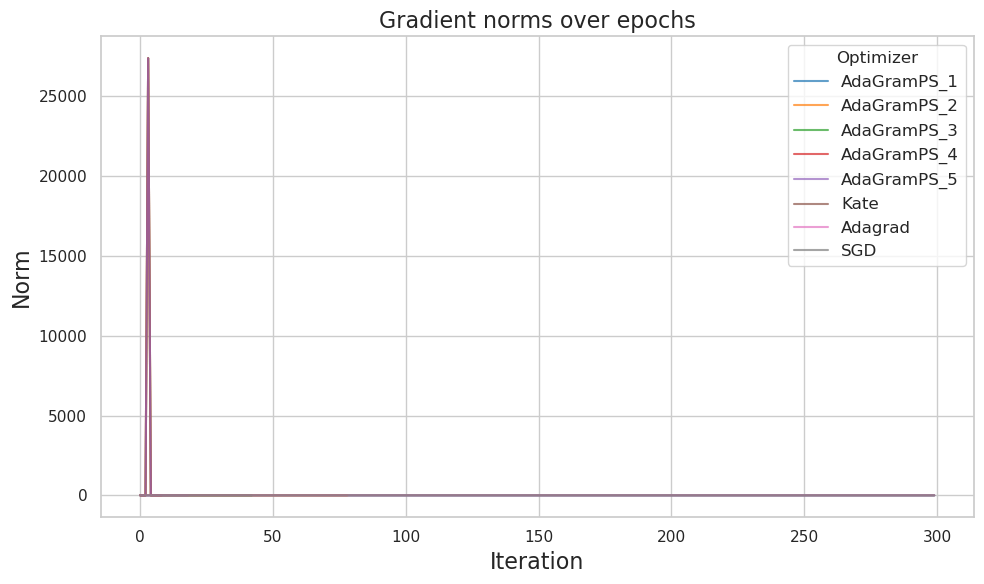

In [8]:
import math
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- 1. Data Preparation: Convert to a Long-Form DataFrame ---
# This is the most important step for using Seaborn.
# We transform the data from a dictionary to a list of records.
# data_list = []
# for opt_name, values in metrics.items():
#     for i, angle in enumerate(values["g_angles"]):
#         data_list.append({
#             "Optimizer": opt_name,
#             "Iteration": i,
#             "Gradient Angle": angle,
#             "Norm": values["gs"][i]
#         })

# df = pd.DataFrame(data_list)

# --- 2. Plotting with Seaborn ---
# Set the plot style and size
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Define the color palette and markers from your original config
palette = {opt['name']: opt['color'] for opt in optimizers_config}
markers = ['o', 's', '^', 'D', 'v', '*', 'p', 'X']

# Create the main line plot using Seaborn's lineplot function
# Seaborn handles the legend and colors automatically based on the 'hue' column.
sns.lineplot(
    data=df,
    x="Iteration",
    y="Norm",
    hue="Optimizer",
    palette=palette,
    alpha=0.7,
    ax=ax
)

# # --- 3. Add Markers Manually ---
# # We still add markers separately to have full control over the `markevery` logic.
# for i, name in enumerate(df['Optimizer'].unique()):
#     optimizer_df = df[df['Optimizer'] == name]
#     ax.plot(
#         optimizer_df["Iteration"],
#         optimizer_df["Gradient Angle"],
#         color=palette[name],
#         linestyle='None',
#         marker=markers[i % len(markers)],
#         markevery=50,
#         markersize=8,
#         alpha=0.6,
#         label='_nolegend_'
#     )

# --- 4. Final Formatting ---
# Use Matplotlib functions to apply the final custom touches
ax.set_title('Gradient norms over epochs', fontsize=16)
ax.set_xlabel('Iteration', fontsize=16)
ax.set_ylabel('Norm', fontsize=16)

# ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
# ax.set_yticks([-math.pi, -math.pi/2, 0, math.pi/2, math.pi])
# ax.set_yticklabels([r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])

# # Improve the legend generated by Seaborn
ax.legend(title='Optimizer', fontsize=12)

plt.tight_layout()
plt.show()



In [ ]:
!pip install plotly

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [ ]:
import numpy as np
import torch
import plotly.graph_objects as go

# (Assuming your function 'f' and BOUNDS are defined)
def f(w):
    w1, w2 = w
    return (w1 - 1)**2 + (w2 - 1)**2

BOUNDS_W1 = (-3, 3)
BOUNDS_W2 = (-3, 3)

# Create the data
x_grid = np.linspace(*BOUNDS_W1, 50)
y_grid = np.linspace(*BOUNDS_W2, 50)
X, Y = np.meshgrid(x_grid, y_grid)
Z = np.array([f(torch.tensor([x_val, y_val], dtype=torch.float32)).item() for x_val, y_val in zip(X.flatten(), Y.flatten())]).reshape(X.shape)

# Create the interactive 3D surface plot with a valid Plotly colorscale
fig = go.Figure(data=[go.Surface(z=Z, x=X, y=Y, colorscale='RdBu_r', opacity=0.8)])

fig.update_layout(
    title='Interactive 3D Surface Plot',
    scene=dict(
        xaxis_title='W1',
        yaxis_title='W2',
        zaxis_title='f(W)'
    ),
    autosize=False,
    width=800,
    height=600
)

fig.show()


In [ ]:
import torch
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import LogNorm

import libcontext
from src.adagram_optimizers.AdagramVanilla import AdaGramVanilla
from src.adagram_optimizers.AdagramPS import AdaGramPS
from src.adagram_optimizers.Shampoo import Shampoo
from src.adagram_optimizers.FullAdagrad import FullAdaGrad
from src.adagram_optimizers.Kate import KATE

from IPython.display import HTML
import matplotlib

matplotlib.rcParams['animation.embed_limit'] = 50

# --- Matplotlib Configuration ---
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['grid.linestyle'] = ":"
plt.rcParams['figure.dpi'] = 100

# --- Rosenbrock Function using PyTorch ---
def f(w):
    """Rosenbrock function for optimization."""
    w1, w2 = w
    return (1 - w1)**2 + 100 * (w2 - w1**2)**2

# --- Simulation Parameters ---
N_ITER = 2000
TOTAL_FRAMES = 300
LR = 5e-3
MOMENTUM = 0.9
W_0 = torch.tensor([0.1, 3.0])
BOUNDS_W1 = (-2, 2)
BOUNDS_W2 = (-1, 3)

# --- Optimizer Configuration ---
# Note: Replaced Optax optimizers with PyTorch equivalents.
optimizers_config = [
    # {
    #     'name': 'RMSprop',
    #     'optimizer_class': torch.optim.RMSprop,
    #     'params': {'lr': LR},
    #     'color': 'orange'
    # },
    {
        'name': 'AdaGramPS',
        'optimizer_class': AdaGramPS,
        'params': {'lr': LR, 'max_rank': 1},
        'color': 'red'
    },
        {
        'name': 'Kate',
        'optimizer_class': KATE,
        'params': {'lr': LR},
        'color': 'purple'
    },
    {
        'name': 'Adagrad',
        'optimizer_class': torch.optim.Adagrad,
        'params': {'lr': LR},
        'color': 'green'
    },
    {
        'name': 'SGD',
        'optimizer_class': torch.optim.SGD,
        'params': {'lr': LR},
        'color': 'orange'
    },
    # {
    #     'name': 'AdamW',
    #     'optimizer_class': torch.optim.AdamW,
    #     'params': {'lr': LR},
    #     'color': 'purple'
    # },
]

# --- Trajectory Calculation Logic for PyTorch ---
def optimizer_trajectory(optimizer, w, n_iter=N_ITER):
    """
    Computes the optimization trajectory for a given PyTorch optimizer.
    # """
    # w = initial_w.clone().detach().requires_grad_(True)
    
    metrics = {
        "fs": [],
        "gs": [],
        "ws": [],
    }

    # Initial state
    initial_loss = f(w)
    initial_loss.backward()
    metrics["fs"].append(initial_loss.item())
    metrics["gs"].append(torch.linalg.norm(w.grad).item())
    metrics["ws"].append(w.clone().detach())
    optimizer.zero_grad()

    # Optimization loop
    for _ in range(n_iter):
        
        loss = f(w)
        loss.backward()
        optimizer.step()

        # Record metrics
        metrics["fs"].append(loss.item())
        metrics["gs"].append(torch.linalg.norm(w.grad).item())
        metrics["ws"].append(w.clone().detach())
        optimizer.zero_grad()
        
    return metrics

# --- Run Optimization for All Configured Optimizers ---
metrics = {}
for opt_config in optimizers_config:
    # Create the tensor that will be optimized for this run
    w_to_optimize = W_0.clone().detach().requires_grad_(True)
    
    # Instantiate the optimizer with THIS specific tensor
    optimizer_instance = opt_config['optimizer_class']([w_to_optimize], **opt_config['params'])
    
    print(f"Running optimizer: {opt_config['name']}...")
    # Pass both the optimizer and the tensor it's tracking
    metrics[opt_config['name']] = optimizer_trajectory(optimizer_instance, w_to_optimize)

print("All optimizations complete.")
# --- 3D Plot Setup ---
fig, ax = plt.subplots(subplot_kw=dict(projection='3d', azim=-128.0, elev=43.0, computed_zorder=False), figsize=(8, 6))

# Create the surface plot
x_grid = np.linspace(*BOUNDS_W1, 50)
y_grid = np.linspace(*BOUNDS_W2, 50)
X, Y = np.meshgrid(x_grid, y_grid)
Z = np.array([f(torch.tensor([x_val, y_val])).item() for x_val, y_val in zip(X.flatten(), Y.flatten())]).reshape(X.shape)

ax.plot_surface(X, Y, Z, alpha=0.6, cmap='coolwarm', norm=LogNorm())
ax.set_xlabel(r'$w_1$')
ax.set_ylabel(r'$w_2$')
ax.set_xlim(BOUNDS_W1)
ax.set_ylim(BOUNDS_W2)
ax.set_zlim([0, 2500])
ax.zaxis.set_rotate_label(False)
ax.set_zlabel(r'$f(w)$', rotation=0)
ax.set_title(f'Rosenbrock Function Optimization in PyTorch\nLearning Rate: {LR}')

# Plot the global minimum
global_min = torch.tensor([1.0, 1.0])
ax.scatter(global_min[0], global_min[1], f(global_min).item(), color='gold', marker='*', s=300, label='Optimal Solution')

# Initialize empty lines for trajectories - extract the Line3D object from the list
lines = [ax.plot([], [], [], color=opt['color'], label=opt['name'])[0] for opt in optimizers_config]

ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

# --- Animation Logic ---
last_scatters = []

def animate(i):
    global last_scatters
    ax.view_init(azim=-128.0, elev=43.0)
    
    skip_rate = int(np.floor(N_ITER / TOTAL_FRAMES))
    if skip_rate == 0: skip_rate = 1
    
    for scatter in last_scatters:
        scatter.remove()
    last_scatters.clear()
    
    for opt_config, line in zip(optimizers_config, lines):
        name = opt_config['name']
        
        # Calculate the current slice of the trajectory
        end_index = min(i * skip_rate + 1, len(metrics[name]["ws"]))
        w_trajectory_torch = torch.stack(metrics[name]["ws"][:end_index])
        w_trajectory_np = w_trajectory_torch.numpy()
        
        # --- FIX: Use pre-computed Z-values ---
        z_trajectory = metrics[name]["fs"][:end_index]
        
        line.set_data(w_trajectory_np[:, 0], w_trajectory_np[:, 1])
        line.set_3d_properties(z_trajectory) # Use the stored values

        # Draw current point
        w_current = w_trajectory_torch[-1]
        z_current = z_trajectory[-1] # Get the corresponding z-value
        scatter = ax.scatter(w_current[0], w_current[1], z_current, color=opt_config['color'], s=40)
        last_scatters.append(scatter)

    return lines + last_scatters
# To run the animation, you would uncomment the following lines:
ani = FuncAnimation(
    fig,
    animate,
    interval=1000/30,  # Increased interval for clearer visualization
    frames=TOTAL_FRAMES,
    blit=True
)

ani.save(
    "rosenbrock_optimization.mp4", 
    writer='ffmpeg', 
    fps=30,
    # This is the key for speed
    extra_args=['-vcodec', 'libx264', '-preset', 'ultrafast']
)


# animate(TOTAL_FRAMES)
# fig.tight_layout(rect=[0, 0.03, 1, 1])
# # plt.show()
# HTML(ani.to_jshtml())